In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('DCOILBRENTEU.csv')
df['DCOILBRENTEU'] = pd.to_numeric(df['DCOILBRENTEU'], errors='coerce').ffill()
df['observation_date'] = pd.to_datetime(df['observation_date'])
df = df[df['observation_date']>='2025-01-01']


df_oil_weekly = df.resample('W-SUN', on='observation_date').mean().reset_index()
df_oil_weekly.columns = ['Observation_Date', 'Price($)/Litre']

df_trends = pd.read_csv("EV Trends.csv", skiprows=2)
df_trends.columns = ['Date', 'EV_Trend_Score']
df_trends['Date'] = pd.to_datetime(df_trends['Date'])

df_final = pd.merge(df_oil_weekly, df_trends, left_on='Observation_Date', right_on='Date')

df_final['Price($)/Litre'] = df_final['Price($)/Litre'] / 159
df_final['Price($)/Litre'] = df_final['Price($)/Litre'].round(2)

df_final.head()


,Observation_Date,Price($)/Litre,Date,EV_Trend_Score
0,2025-09-14,0.42,2025-09-14,52
1,2025-09-21,0.43,2025-09-21,53
2,2025-09-28,0.44,2025-09-28,51
3,2025-10-05,0.42,2025-10-05,52
4,2025-10-12,0.42,2025-10-12,48


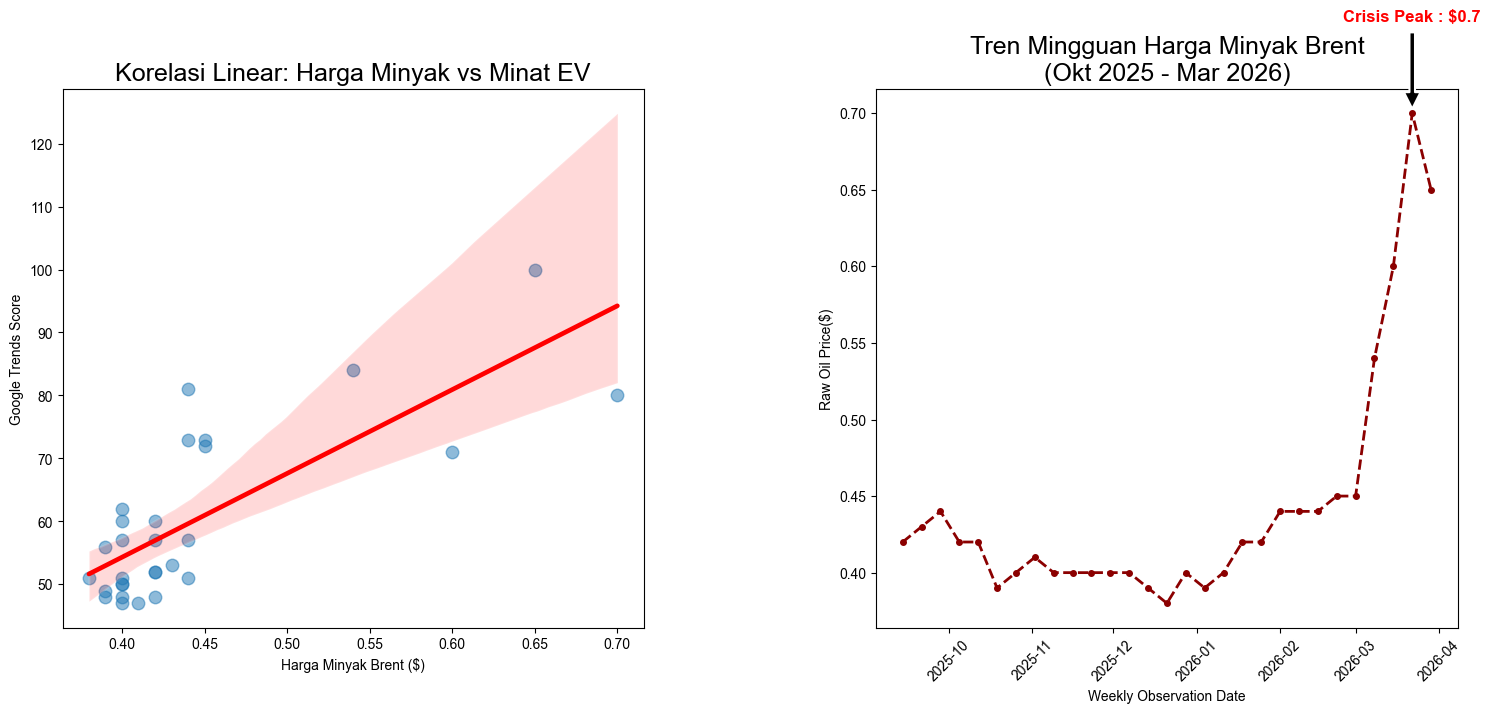

In [3]:
fig,(ax1, ax2) = plt.subplots(1, 2,figsize=(18,7))
sns.set_theme('talk')


sns.regplot(data=df_final, x='Price($)/Litre', y='EV_Trend_Score', ax=ax1, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax1.set_title('Korelasi Linear: Harga Minyak vs Minat EV')
ax1.set_xlabel('Harga Minyak Brent ($)')
ax1.set_ylabel('Google Trends Score')

ax2.plot(df_final['Observation_Date'], df_final['Price($)/Litre'], marker='o', linestyle='dashed', color='darkred', linewidth=2, markersize=4)

max_price = df_final['Price($)/Litre'].max()
max_date = df_final.loc[df_final['Price($)/Litre'].idxmax(), 'Observation_Date']

ax2.annotate(
    f'Crisis Peak : ${max_price}',
    xy=(max_date, max_price),
    xytext=(max_date, max_price+0.06),
    arrowprops=dict(facecolor='black', shrink=0.05),
    fontsize=12, fontweight='bold', color='red',
    ha='center'
)

ax2.set_title('Tren Mingguan Harga Minyak Brent\n(Okt 2025 - Mar 2026)')
ax2.set_xlabel('Weekly Observation Date')
ax2.set_ylabel('Raw Oil Price($)')

plt.setp(ax2.get_xticklabels(), rotation=45)
plt.subplots_adjust(wspace=0.4)

plt.show()

In [4]:
df_indo_trends = pd.read_csv("Indonesia_EV_Trends.csv")
df_malay_trends = pd.read_csv("Malaysia_EV_Trends.csv")
df_norway_trends = pd.read_csv("Norway_EV_Trends.csv")
df_singapore_trends = pd.read_csv("Singapore_EV_Trends.csv")
df_USA_trends = pd.read_csv("US_EV_Trends.csv")

df_indo_trends.columns = ['Observation Date', 'Indonesia EV Trends']
df_malay_trends.columns = ['Observation Date', 'Malaysia EV Trends']
df_norway_trends.columns = ['Observation Date', 'Norway EV Trends']
df_USA_trends.columns = ['Observation Date', 'USA EV Trends']
df_singapore_trends.columns = ['Observation Date', 'Singapore EV Trends']

df_indo_trends['Observation Date'] = pd.to_datetime(df_indo_trends['Observation Date'])
df_malay_trends['Observation Date'] = pd.to_datetime(df_malay_trends['Observation Date'])
df_norway_trends['Observation Date'] = pd.to_datetime(df_norway_trends['Observation Date'])
df_USA_trends['Observation Date'] = pd.to_datetime(df_USA_trends['Observation Date'])
df_singapore_trends['Observation Date'] = pd.to_datetime(df_singapore_trends['Observation Date'])

df_indo_final = pd.merge(df_indo_trends, df_final[['Observation_Date', 'Price($)/Litre']], left_on='Observation Date', right_on='Observation_Date', how='inner')

df_malay_final = pd.merge(df_malay_trends, df_final[['Observation_Date', 'Price($)/Litre']], left_on='Observation Date', right_on='Observation_Date', how='inner')

df_norway_final = pd.merge(df_norway_trends, df_final[['Observation_Date', 'Price($)/Litre']], left_on='Observation Date', right_on='Observation_Date', how='inner')

df_USA_final = pd.merge(df_USA_trends, df_final[['Observation_Date', 'Price($)/Litre']], left_on='Observation Date', right_on='Observation_Date', how='inner')

df_singapore_final = pd.merge(df_singapore_trends, df_final[['Observation_Date', 'Price($)/Litre']], left_on='Observation Date', right_on='Observation_Date', how='inner')




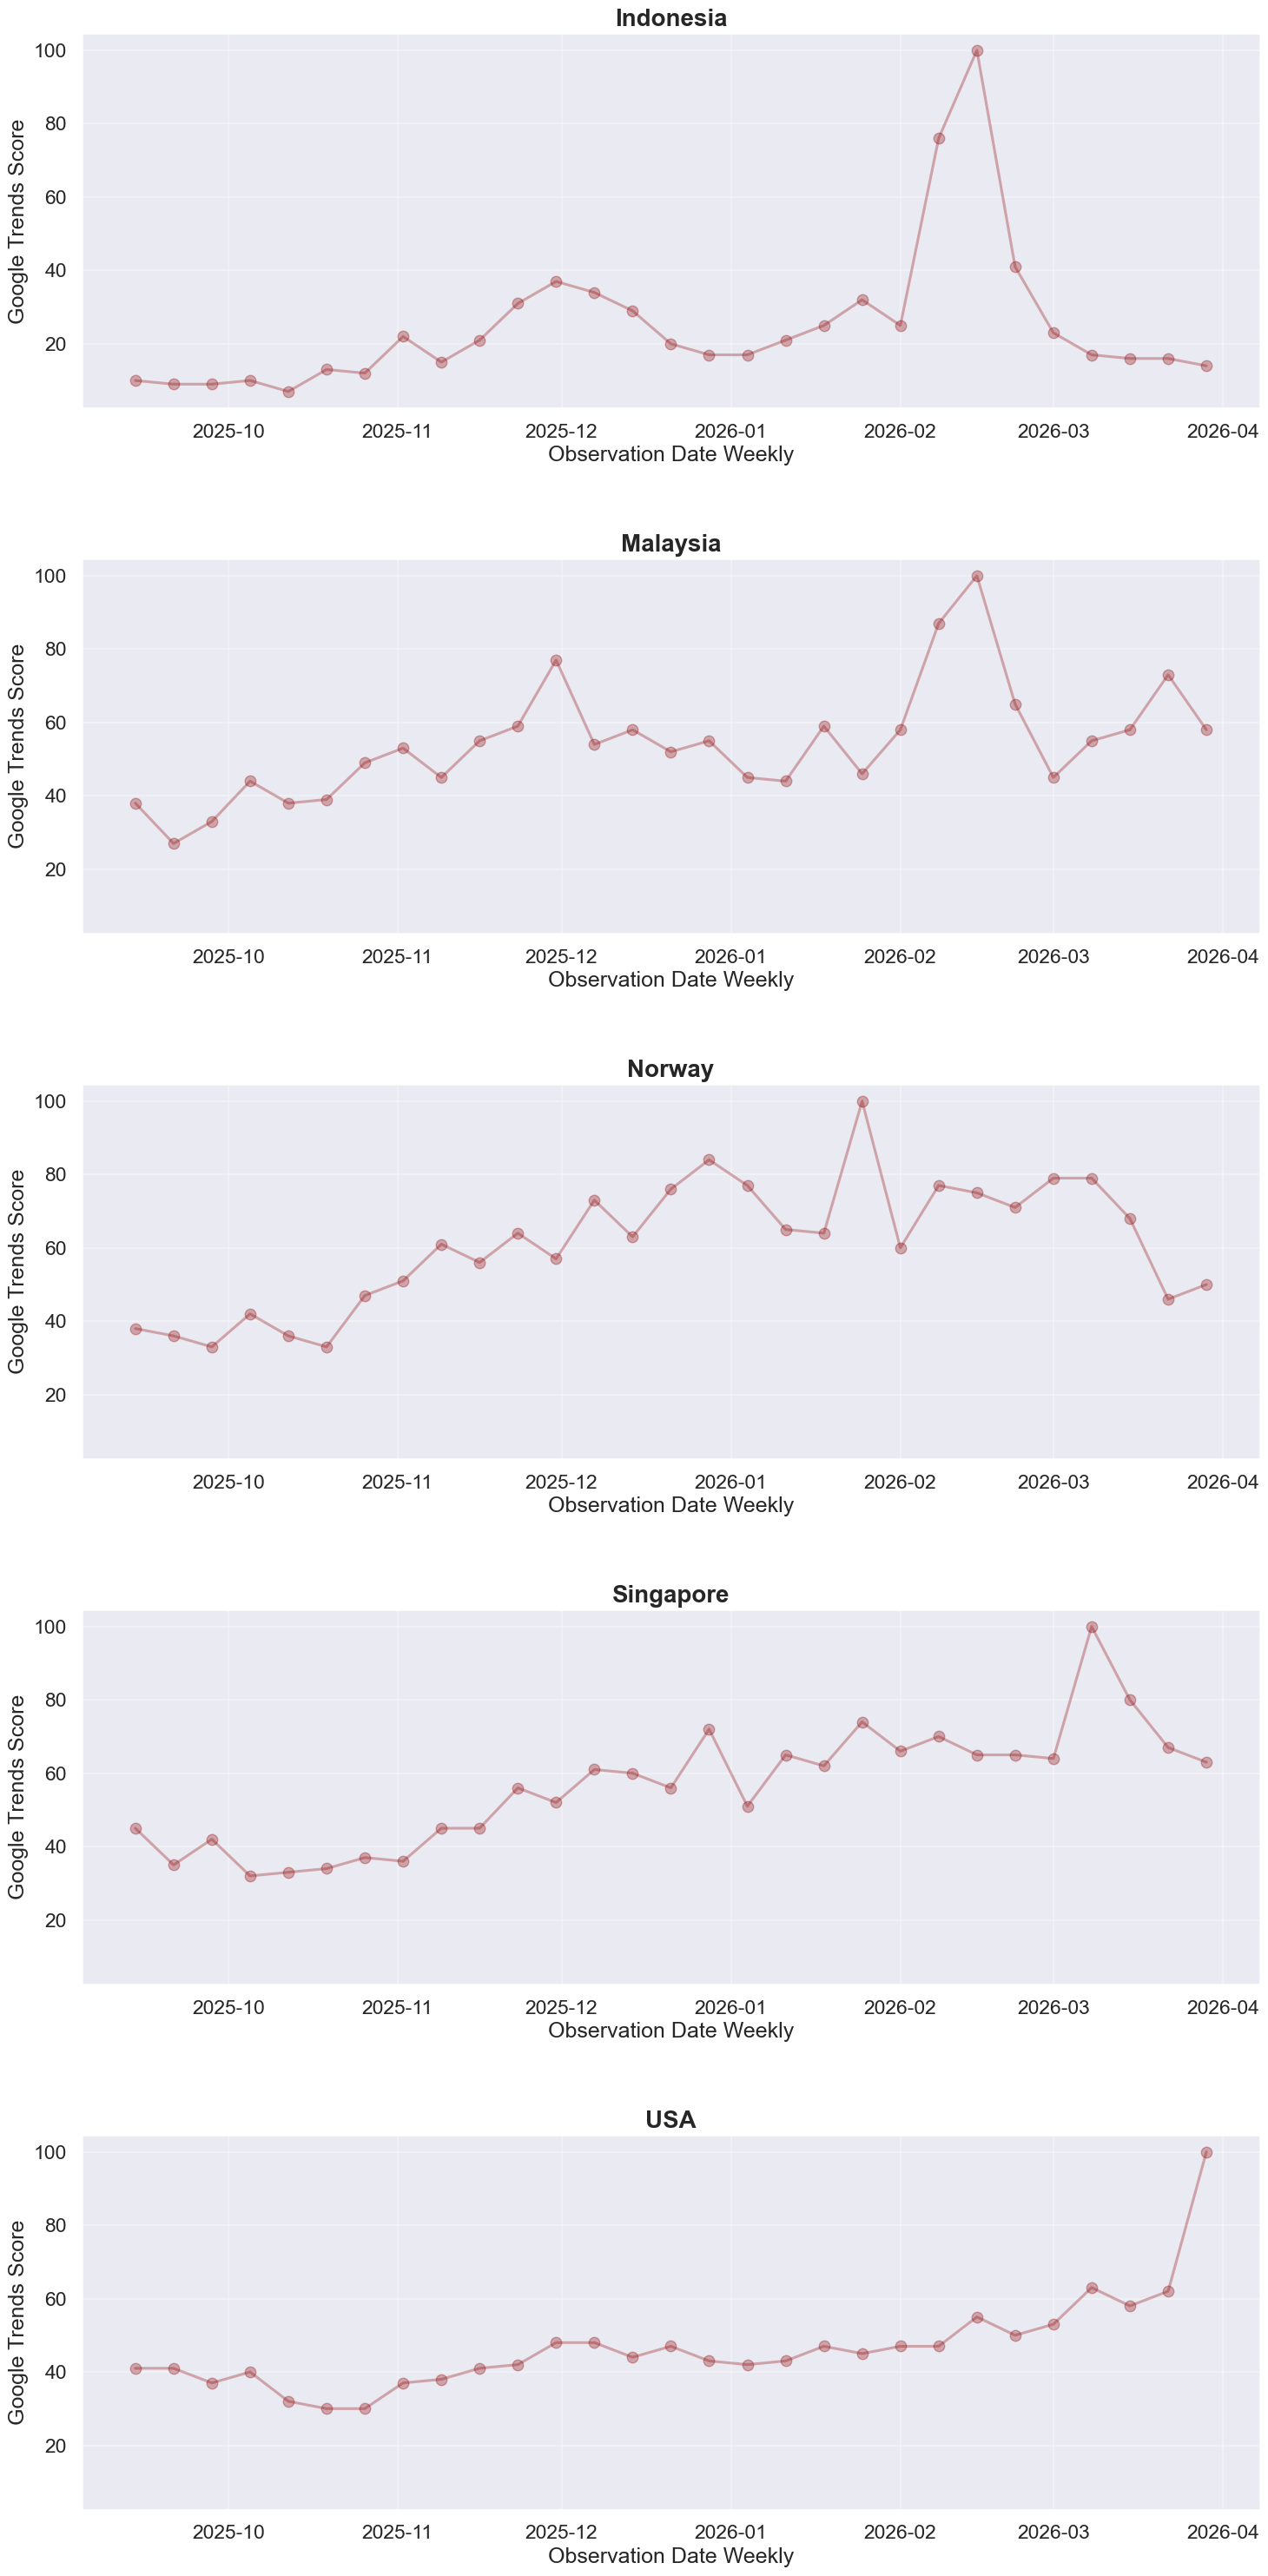

In [5]:
finals = [df_indo_final, df_malay_final, df_norway_final, df_singapore_final, df_USA_final]
titles = ['Indonesia', 'Malaysia', 'Norway', 'Singapore', 'USA']
colors = ['red', 'yellow', 'gray', 'white', 'blue']
trend_cols = [
    'Indonesia EV Trends',
    'Malaysia EV Trends',
    'Norway EV Trends',
    'Singapore EV Trends',
    'USA EV Trends'
]

fig, axes = plt.subplots(5,1, figsize=(15,30), sharey=True)
sns.set_theme('talk')

for i, ax in enumerate(axes):
    ax.plot(finals[i]['Observation Date'], finals[i][trend_cols[i]],
            linestyle='solid', marker='o', color='darkred', alpha=0.3, label='Oil Price')
    ax.set_title(titles[i], fontsize=20, fontweight='bold')
    ax.set_ylabel('Google Trends Score')
    ax.set_xlabel('Observation Date Weekly')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

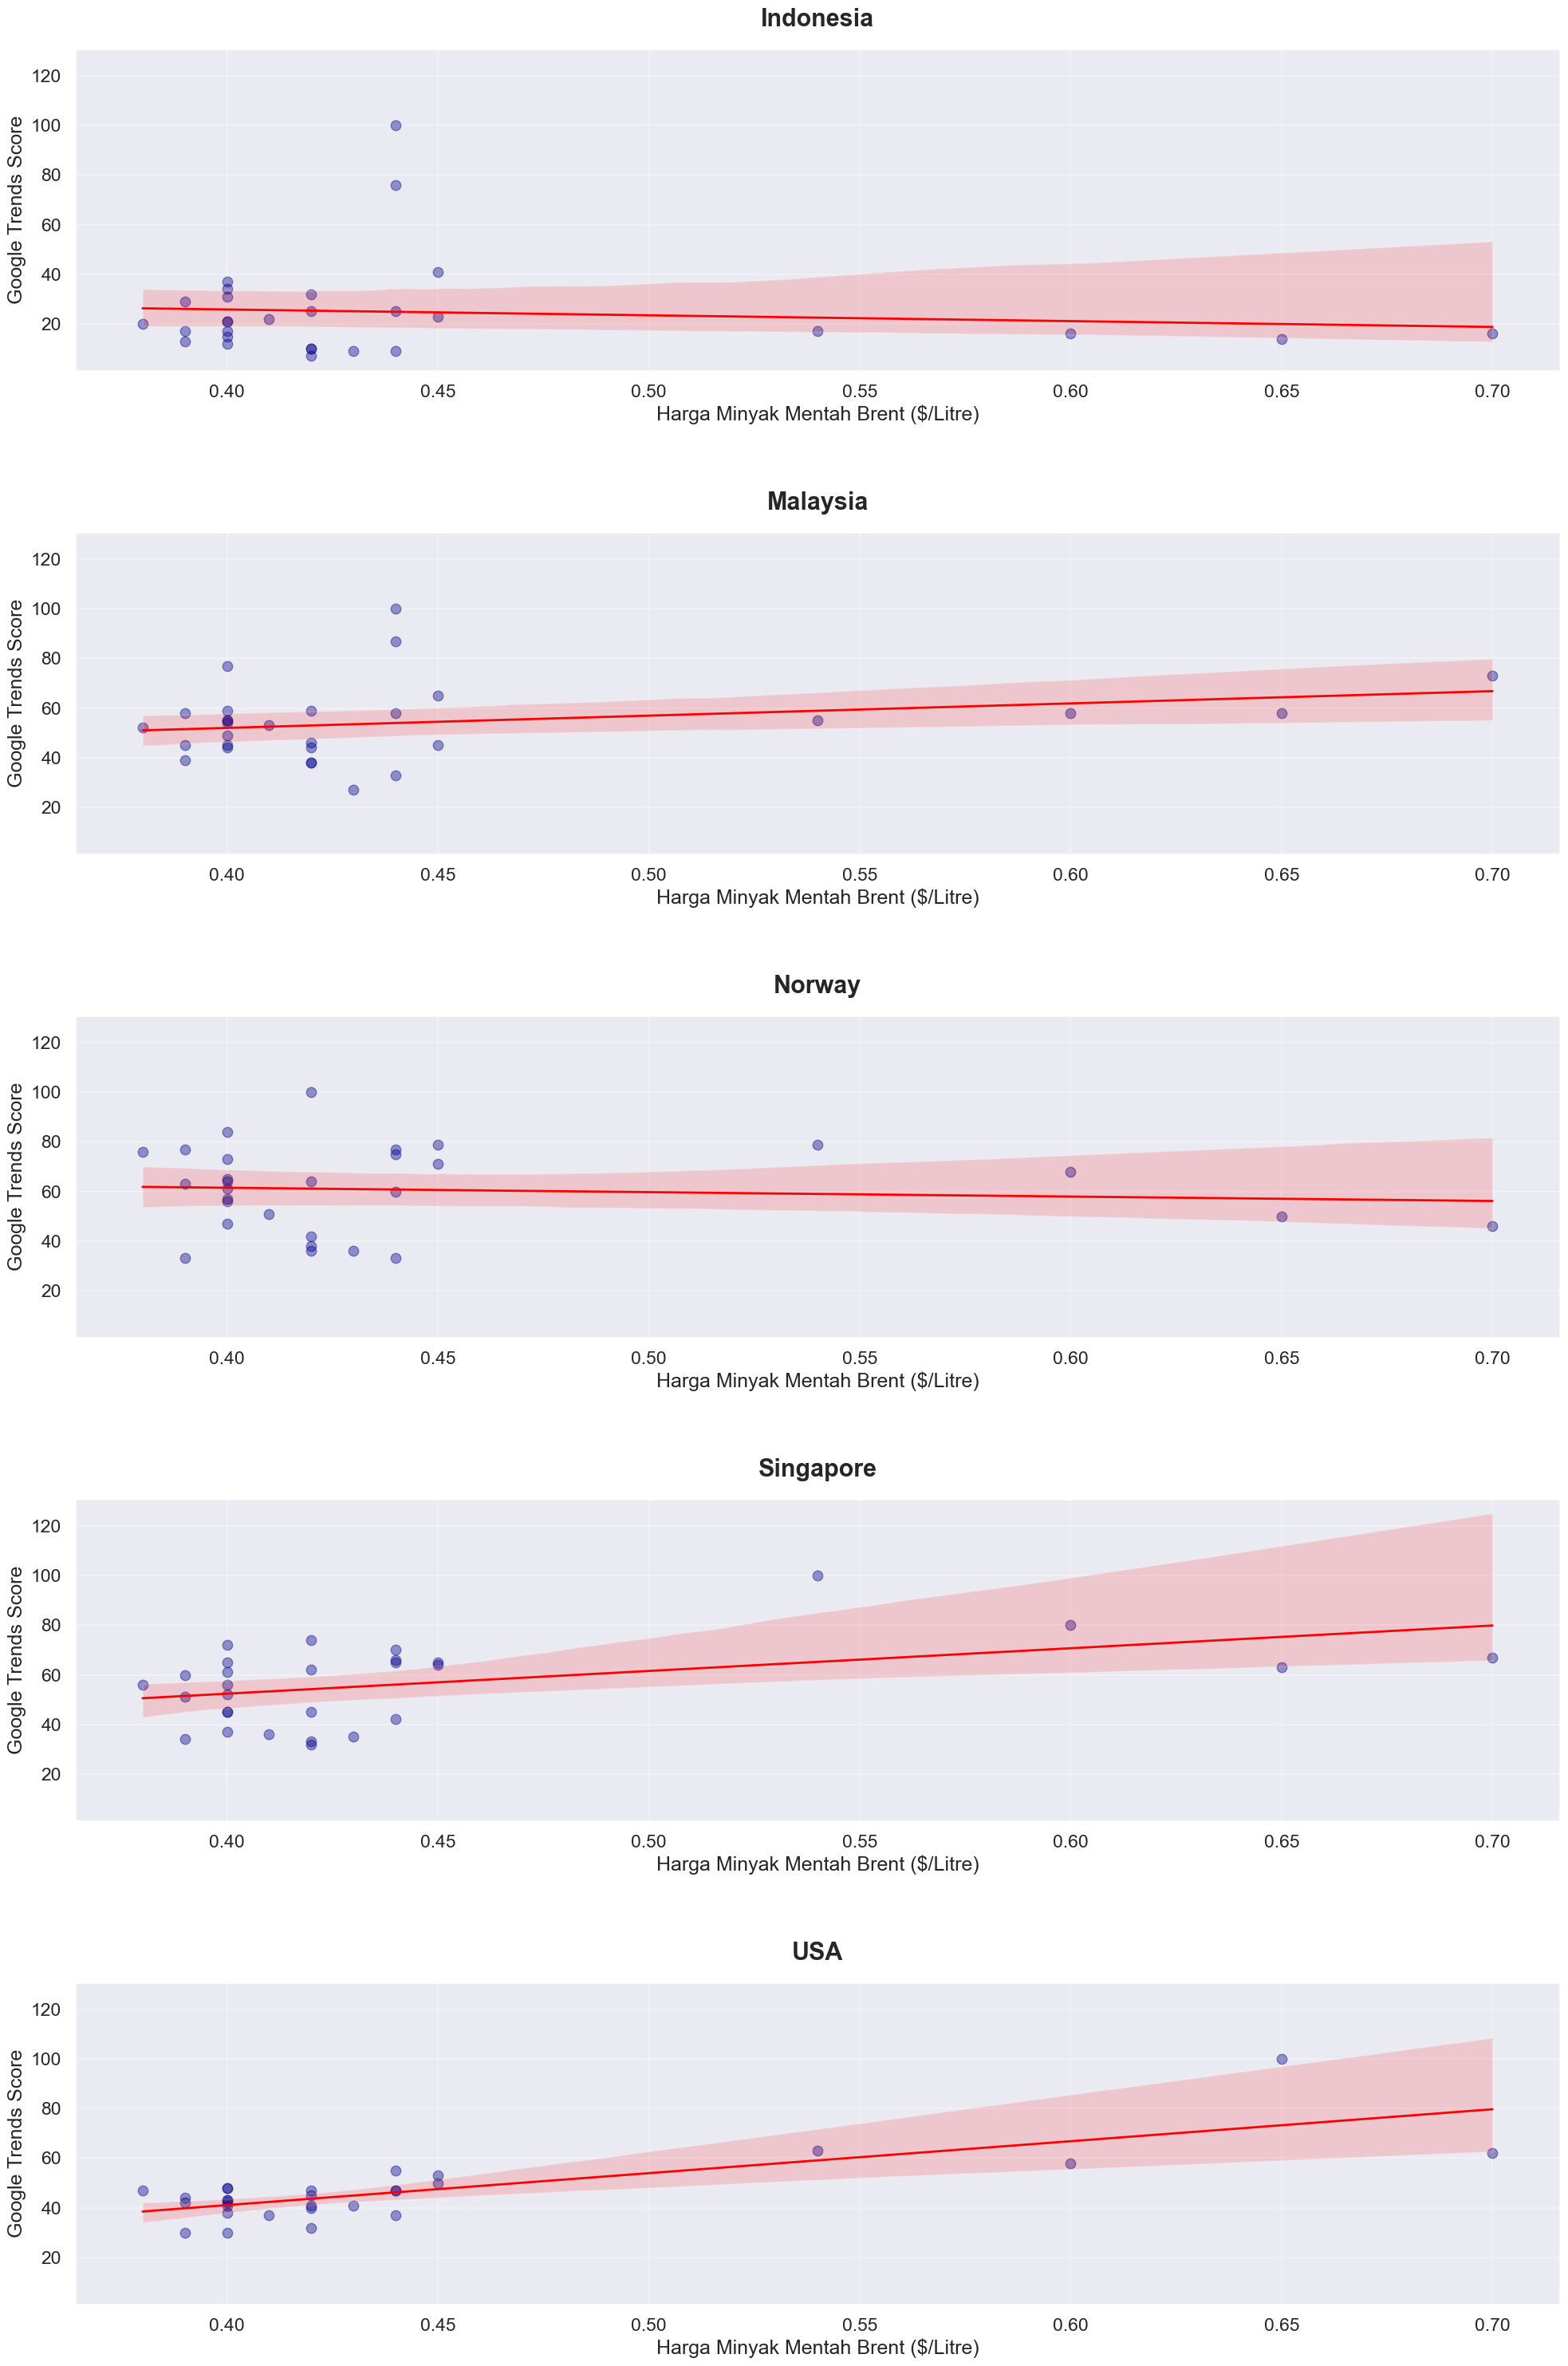

In [6]:
fig, axes = plt.subplots(5,1, figsize=(20,30), sharey=True)
for i, ax in enumerate(axes):
    sns.regplot(
        x=finals[i]['Price($)/Litre'],
        y=finals[i][trend_cols[i]],
        ax = ax,
        scatter_kws={'alpha':0.4, 'color':'darkblue'},
        line_kws={'color':'red', 'lw':2}
    )

    ax.set_title(titles[i], fontsize=22, fontweight ='bold', pad=20)
    ax.set_xlabel('Harga Minyak Mentah Brent ($/Litre)')
    ax.set_ylabel('Google Trends Score')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_6592\2621556611.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=df_summary, x='Country',y='Average Score', palette=colors)


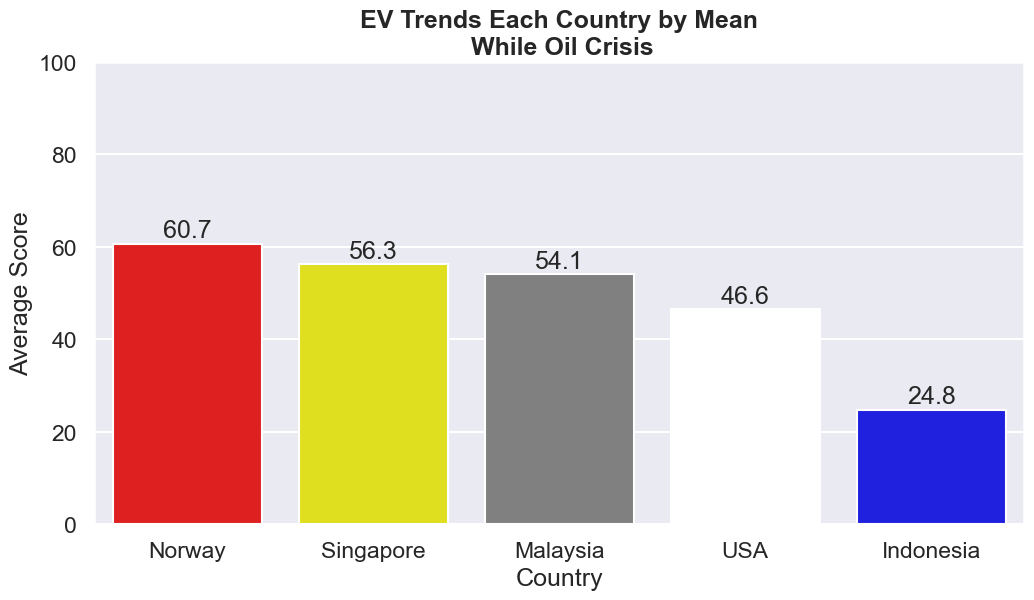

In [7]:


avg_score = [df[col].mean() for df, col in zip(finals, trend_cols)]

df_summary = pd.DataFrame({
    'Country':titles,
    'Average Score': avg_score
})
df_summary = df_summary.sort_values('Average Score', ascending=False)

plt.figure(figsize=(12,6))
sns.set_theme('talk')
plot = sns.barplot(data=df_summary, x='Country',y='Average Score', palette=colors)

for p in plot.patches:
    plot.annotate(format(p.get_height(), '.1f'),
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va='center',
                  xytext=(0,9),
                  textcoords='offset points')

plt.title('EV Trends Each Country by Mean\n While Oil Crisis', fontsize=18, fontweight='bold')
plt.ylim(0,100)
plt.show()

In [8]:
from functools import reduce

df_worldwide = df_trends[['Date', 'EV_Trend_Score']].rename(columns={
    'Date' : 'Observation Date',
    'EV_Trend_Score' : 'Worldwide Trends'
})

df_worldwide['Observation Date'] = pd.to_datetime(df_worldwide['Observation Date'])

clean_data_frames = [
    df_worldwide,
    df_indo_final[['Observation Date', 'Price($)/Litre','Indonesia EV Trends']],
    df_malay_final[['Observation Date', 'Malaysia EV Trends']],                
    df_norway_final[['Observation Date', 'Norway EV Trends']],
    df_singapore_final[['Observation Date', 'Singapore EV Trends']],
    df_USA_final[['Observation Date', 'USA EV Trends']]
]

df_final = reduce(lambda left, right: pd.merge(left, right, on='Observation Date', how='inner'), clean_data_frames)



max_oil_price = df_final['Price($)/Litre'].max()

global_trend_peak = df_final['Worldwide Trends'].max()

the_panic_week = df_final.loc[df_final['Worldwide Trends'].idxmax(), 'Observation Date']

display(df_final)

country_cols = ['Indonesia EV Trends', 'Malaysia EV Trends', 'Norway EV Trends', 'Singapore EV Trends', 'USA EV Trends']
avg_per_country = df_final[country_cols].mean()
top_country = avg_per_country.idxmax().replace(' EV Trends', '')
top_value = avg_per_country.max()

print(f'---- KPI SCORECARDDATA ----')
print(f'Harga Tertinggi saat Krisis Bensin Dunia adalah {max_oil_price}$/Litre')
print(f'Puncak Ketertarikan dunia pada EV berada di score {global_trend_peak} dilansir dari score Google Trends secara World Wide')
print(f'Tanggal saat pencarian mencapai puncak {the_panic_week}')
print(f'Pasar paling antusias: {top_country} ({top_value:.1f} avg)')



,Observation Date,Worldwide Trends,Price($)/Litre,Indonesia EV Trends,Malaysia EV Trends,Norway EV Trends,Singapore EV Trends,USA EV Trends
0,2025-09-14,52,0.42,10,38,38,45,41
1,2025-09-21,53,0.43,9,27,36,35,41
2,2025-09-28,51,0.44,9,33,33,42,37
3,2025-10-05,52,0.42,10,44,42,32,40
4,2025-10-12,48,0.42,7,38,36,33,32
5,2025-10-19,49,0.39,13,39,33,34,30
6,2025-10-26,47,0.40,12,49,47,37,30
7,2025-11-02,47,0.41,22,53,51,36,37
8,2025-11-09,50,0.40,15,45,61,45,38
9,2025-11-16,50,0.40,21,55,56,45,41


---- KPI SCORECARDDATA ----
Harga Tertinggi saat Krisis Bensin Dunia adalah 0.7$/Litre
Puncak Ketertarikan dunia pada EV berada di score 100 dilansir dari score Google Trends secara World Wide
Tanggal saat pencarian mencapai puncak 2026-03-29 00:00:00
Pasar paling antusias: Norway (60.7 avg)


In [9]:
df_final.to_csv("final_data.csv", index= False)